# Visualisation Group Work

You can use this notebook as a template and add your plots in the cells below. We've already added some code to import the necessary packages and included an example plot to show you how a good plot might look like. 

Now it's you your turn to create your first plots with Python's plotting libraries. At the end of this exercise your notebook should contain one plot per library. Since you will share your notebook with the other groups, make sure to add comments so it's easy for them to understand your code. 

Your group number will tell you which kind of plot and data set you should use for the exercise. 

| Group | Plot | Dataset | 
|-------|------|---------|
|  1 | Scatterplot | Seattle Weather |
|  2 | Lineplot | Seattle Weather | 
|  3 | Barchart | Seattle Weather  | 
|  4 | Geographical Maps | Airports  | 
 



## What makes a plot good?

For this exercise the charts do not have to be particularly fancy or provide mind-blowing insights into the data, but they should contain all the elements that make a good plot.
Take the following plot as an example:

![example_plot](image/example_plot.png)

Like the plot above your figures should have/be...
1. ... a meaningful title.
2. ... labels (with units when necessary) on both axis. 
3. ... a legend (if necessary). Make sure it doesn't overlap other important elements.
3. ... text that is easliy readable. You can change and increase the font size, rotate tick labels, flip axis etc. to improve readabilty. 
4. ... not overloaded with information. Try to keep it rather clean and simple.

In [2]:
#Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt

## Import Data
Start by importing the data. We added some lines of code for the groups that work with the seattle weather data to help you get started. Depending on how you name your dataframe, you might have to slightly adjust the code in the cell below.

In [3]:
df_airports = pd.read_csv("data_group_work/airports.csv")
df_airports.head()
df_airports.columns = df_airports.columns.str.strip()
print(df_airports.columns.tolist())
df_airports.head()

['iata', 'name', 'city', 'state', 'country', 'latitude', 'longitude']


,iata,name,city,state,country,latitude,longitude
0,00M,Thigpen,Bay Springs,MS,USA,31.953765,-89.234505
1,00R,Livingston Municipal,Livingston,TX,USA,30.685861,-95.017928
2,00V,Meadow Lake,Colorado Springs,CO,USA,38.945749,-104.569893
3,01G,Perry-Warsaw,Perry,NY,USA,42.741347,-78.052081
4,01J,Hilliard Airpark,Hilliard,FL,USA,30.688012,-81.905944


## 1 Matplotlib



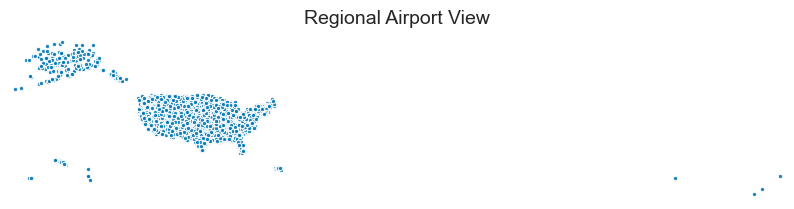

In [10]:
# 1. Setup figure and style
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Create the scatter plot
plt.scatter(
    df_airports['longitude'], 
    df_airports['latitude'], 
    s=10,             # Increased size so they are visible
    c='#0077b6', 
    edgecolors='white', 
    linewidth=0.8,
    alpha=0.9,
    zorder=3
)

# 3. COMPRESSION LOGIC
lon_buffer = 2
lat_buffer = 2

plt.xlim(df_airports['longitude'].min() - lon_buffer, df_airports['longitude'].max() + lon_buffer)
plt.ylim(df_airports['latitude'].min() - lat_buffer, df_airports['latitude'].max() + lat_buffer)

# 4. HIDE AXIS AND TICKS (The "Clean" Part)
plt.axis('off') 

# 5. Fix aspect ratio and polish
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Regional Airport View', fontsize=14, pad=10)

plt.show()

## 2. Seaborn

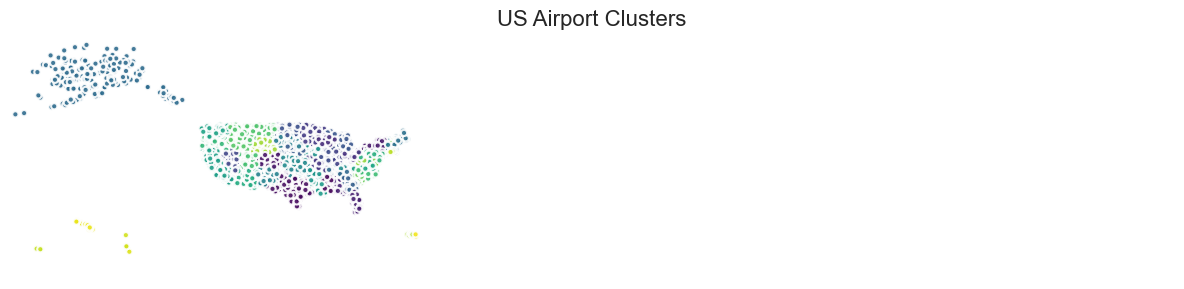

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup the figure
plt.figure(figsize=(12, 8))
sns.set_theme(style="white") 

# 2. Create the plot
ax = sns.scatterplot(
    data=df_airports, 
    x='longitude', 
    y='latitude', 
    hue='state',      
    s=20,            
    palette='viridis', 
    edgecolor='w',    
    linewidth=1.5,
    alpha=0.9,
    legend=False      # This removes the legend entirely
)

# 4. DYNAMIC COMPRESSION
lon_buffer = 1.5
lat_buffer = 1.5
plt.xlim(df_airports['longitude'].min() - lon_buffer, df_airports['longitude'].max() + lon_buffer)
plt.ylim(df_airports['latitude'].min() - lat_buffer, df_airports['latitude'].max() + lat_buffer)

# 5. HIDE EVERYTHING (Axes, Ticks, Labels)
plt.axis('off')

# 6. Maintain Proportions
plt.gca().set_aspect('equal', adjustable='box')
plt.title('US Airport Clusters', fontsize=16, pad=10)

plt.tight_layout()
plt.show()

## 3. Plotly

In [19]:

df_airports['hover_display'] = df_airports['name'] + " (" + df_airports['iata'] + ")"
# 1. Create the geographic scatter plot
fig = px.scatter_geo(
    df_airports,
    lat='latitude',
    lon='longitude',
    # This becomes the bold title of the tooltip
    hover_name='hover_display',      
    # These appear as additional rows in the tooltip
    hover_data={
        'latitude': False,   # Hide coordinates to keep it clean
        'longitude': False, 
        'iata': True, 
        'city': True, 
        'state': True
    },
    color='state',          
    title='US Airports (Hover for Details)',
    scope='usa',            
    template='plotly_white' 
)

# 2. Update marker styling
fig.update_traces(
    marker=dict(
        size=12, 
        line=dict(width=1, color='white'),
        opacity=0.8
    )
)

# 3. Final layout adjustments
fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    title_font_size=20,
    showlegend=True
)

fig.show()

## 4. Altair

In [20]:
import altair as alt

# 1. Direct URL to the US TopoJSON (No vega_datasets required)
us_map_url = "https://cdn.jsdelivr.net/npm/us-atlas@3/states-10m.json"

# 2. Define the background layer using the URL
background = alt.Chart(
    alt.topo_feature(us_map_url, feature='states')
).mark_geoshape(
    fill='#f0f0f0',
    stroke='white'
).project('albersUsa').properties(
    width=800,
    height=500
)

# 3. Define the points layer (Airports)
points = alt.Chart(df_airports).mark_circle(size=120).encode(
    longitude='longitude:Q',
    latitude='latitude:Q',
    color=alt.Color('state:N', legend=alt.Legend(title="State")),
    tooltip=[
        alt.Tooltip('hover_display:N', title='Airport'),
        alt.Tooltip('city:N', title='City'),
        alt.Tooltip('state:N', title='State')
    ]
)

# 4. Layer and display
chart = (background + points).properties(
    title='US Airport Locations (Hover for Details)'
).configure_view(
    stroke=None
)

chart.show()

alt.LayerChart(...)